# Detector de huevos (Crack / Intact) — preparación de datos

Clases: `0 = Crack`, `1 = Intact`. Todo lo persistente vive en Drive (`/content/drive/MyDrive/eggs_v2`); el dataset descomprimido va en el disco local de Colab (`/content/eggs_v2`) porque es mucho más rápido para entrenar.

## 1. GPU y ultralytics
Comprueba que Colab asignó una GPU e instala `ultralytics` (YOLOv8). `checks()` muestra versiones de Python, torch, CUDA y la GPU detectada.

In [6]:
!nvidia-smi
%pip install -q ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.161 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.3/112.6 GB disk)


## 2. Montar Drive y descomprimir los 4 zips
Monta Drive, extrae los 4 zips en `/content/eggs_v2` (todos en la misma carpeta; se fusionan los `train/` de las 3 primeras partes) y comprueba que quedan `train/`, `valid/`, `test/` y `data.yaml`. Si algún zip trae una carpeta raíz extra, lo avisa.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
from pathlib import Path

DRIVE_DIR = Path('/content/drive/MyDrive/eggs_v2')
DATA_DIR = Path('/content/eggs_v2')
DATA_DIR.mkdir(parents=True, exist_ok=True)

zips = [DRIVE_DIR / f for f in [
    'eggs_v2_parte1_train.zip',
    'eggs_v2_parte2_train.zip',
    'eggs_v2_parte3_train.zip',
    'eggs_v2_parte4_valid_test.zip',
]]

for z in zips:
    assert z.exists(), f'No encuentro {z}'
    with zipfile.ZipFile(z) as zf:
        zf.extractall(DATA_DIR)
    print(f'OK  {z.name}')

for name in ['train', 'valid', 'test', 'data.yaml']:
    print(f"{'OK ' if (DATA_DIR / name).exists() else 'FALTA'}  {DATA_DIR / name}")

print('\nContenido de', DATA_DIR, '->', sorted(p.name for p in DATA_DIR.iterdir()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK  eggs_v2_parte1_train.zip
OK  eggs_v2_parte2_train.zip
OK  eggs_v2_parte3_train.zip
OK  eggs_v2_parte4_valid_test.zip
OK   /content/eggs_v2/train
OK   /content/eggs_v2/valid
OK   /content/eggs_v2/test
OK   /content/eggs_v2/data.yaml

Contenido de /content/eggs_v2 -> ['data.yaml', 'data_original.yaml', 'eliminadas.csv', 'test', 'train', 'valid']


## 3. Reescribir `data.yaml` con rutas absolutas
Guarda una copia del original (`data_original.yaml`, solo la primera vez) y escribe un `data.yaml` con rutas absolutas, `nc: 2` y `names: ['Crack', 'Intact']`, para que YOLO no dependa del directorio de trabajo.

In [8]:
import shutil
import yaml

yaml_path = DATA_DIR / 'data.yaml'
backup = DATA_DIR / 'data_original.yaml'
if yaml_path.exists() and not backup.exists():
    shutil.copy(yaml_path, backup)

data_cfg = {
    'path': str(DATA_DIR),
    'train': str(DATA_DIR / 'train/images'),
    'val': str(DATA_DIR / 'valid/images'),
    'test': str(DATA_DIR / 'test/images'),
    'nc': 2,
    'names': ['Crack', 'Intact'],
}
with open(yaml_path, 'w') as f:
    yaml.safe_dump(data_cfg, f, sort_keys=False)

print(yaml_path.read_text())

path: /content/eggs_v2
train: /content/eggs_v2/train/images
val: /content/eggs_v2/valid/images
test: /content/eggs_v2/test/images
nc: 2
names:
- Crack
- Intact



## 4. Conteo por split y por clase + integridad
Para cada split cuenta imágenes, etiquetas, cajas por clase e imágenes que contienen cada clase. Además detecta imágenes sin `.txt`, `.txt` sin imagen, etiquetas vacías y líneas con formato o clase inválidos.

In [9]:
from collections import Counter
import pandas as pd

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
CLASSES = data_cfg['names']

def scan_split(split):
    img_dir, lbl_dir = DATA_DIR / split / 'images', DATA_DIR / split / 'labels'
    imgs = {p.stem: p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS}
    lbls = {p.stem: p for p in lbl_dir.glob('*.txt')}

    boxes, imgs_with = Counter(), Counter()
    empty, bad_lines = [], []
    for stem, lp in lbls.items():
        lines = [l.split() for l in lp.read_text().splitlines() if l.strip()]
        if not lines:
            empty.append(stem)
        present = set()
        for parts in lines:
            if len(parts) != 5 or parts[0] not in {'0', '1'}:
                bad_lines.append((stem, ' '.join(parts)))
                continue
            c = int(parts[0])
            boxes[c] += 1
            present.add(c)
        for c in present:
            imgs_with[c] += 1

    report = {
        'split': split,
        'imagenes': len(imgs),
        'etiquetas': len(lbls),
        'img_sin_txt': len(imgs.keys() - lbls.keys()),
        'txt_sin_img': len(lbls.keys() - imgs.keys()),
        'txt_vacios': len(empty),
        'lineas_invalidas': len(bad_lines),
    }
    for c, name in enumerate(CLASSES):
        report[f'cajas_{name}'] = boxes[c]
        report[f'imgs_con_{name}'] = imgs_with[c]
    missing = sorted(imgs.keys() - lbls.keys())
    return report, missing, bad_lines

rows = []
for split in ['train', 'valid', 'test']:
    report, missing, bad = scan_split(split)
    rows.append(report)
    if missing:
        print(f'[{split}] imágenes sin .txt (primeras 5): {missing[:5]}')
    if bad:
        print(f'[{split}] líneas inválidas (primeras 5): {bad[:5]}')

df = pd.DataFrame(rows).set_index('split')
df.loc['total'] = df.sum()
df['ratio_Crack/Intact'] = (df['cajas_Crack'] / df['cajas_Intact'].replace(0, float('nan'))).round(2)
df

,imagenes,etiquetas,img_sin_txt,txt_sin_img,txt_vacios,lineas_invalidas,cajas_Crack,imgs_con_Crack,cajas_Intact,imgs_con_Intact,ratio_Crack/Intact
split,,,,,,,,,,,
train,2724,2724,0,0,0,0,2115,2110,614,614,3.44
valid,783,783,0,0,0,0,608,605,178,178,3.42
test,382,382,0,0,0,0,301,298,84,84,3.58
total,3889,3889,0,0,0,0,3024,3013,876,876,3.45


## 5. Cuadrícula de 12 imágenes con sus cajas
Elige al azar (semilla fija) 6 imágenes de train con Crack y 6 con Intact y dibuja sus cajas: rojo = Crack, verde = Intact. Sirve para verificar a ojo que las etiquetas cuadran con los huevos.

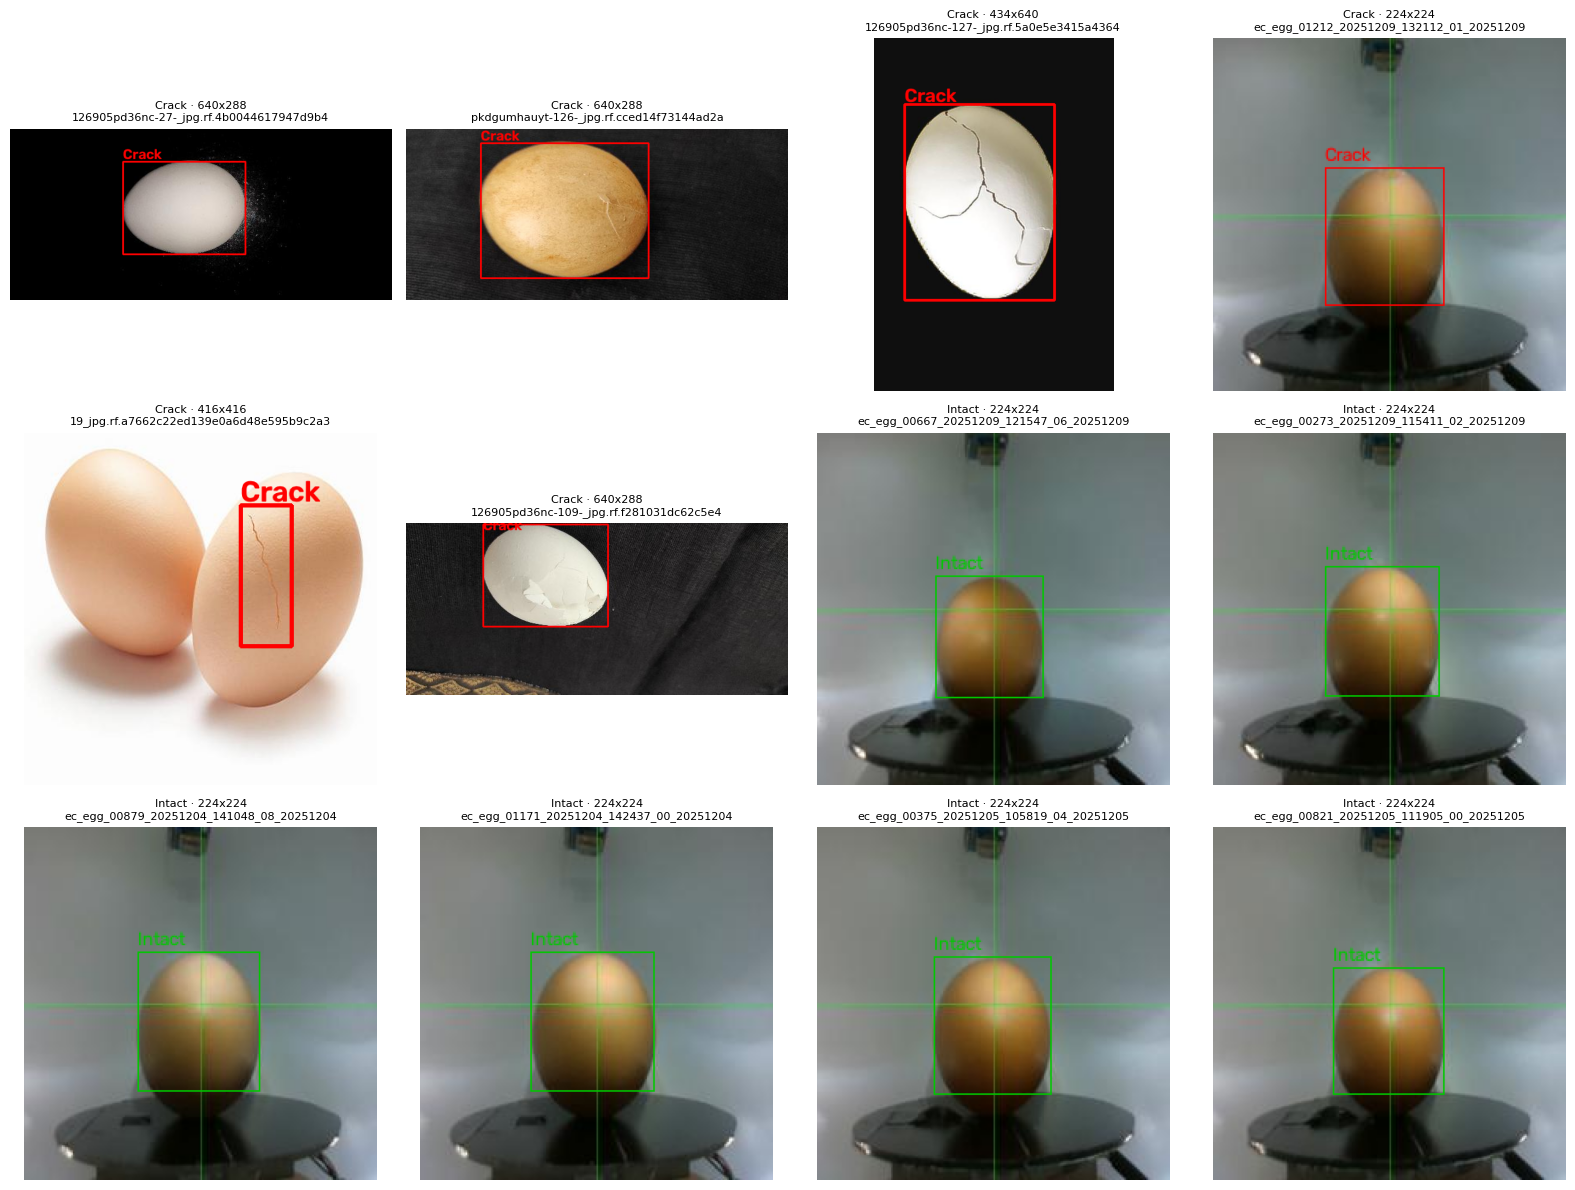

In [10]:
import random
import cv2
import matplotlib.pyplot as plt

random.seed(0)
COLORS = {0: (255, 0, 0), 1: (0, 200, 0)}  # RGB: Crack rojo, Intact verde

def read_labels(lbl_path):
    out = []
    for line in lbl_path.read_text().splitlines():
        parts = line.split()
        if len(parts) == 5:
            out.append((int(parts[0]), *map(float, parts[1:])))
    return out

def images_with_class(split, cls):
    lbl_dir, img_dir = DATA_DIR / split / 'labels', DATA_DIR / split / 'images'
    img_by_stem = {p.stem: p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS}
    return [img_by_stem[lp.stem] for lp in lbl_dir.glob('*.txt')
            if lp.stem in img_by_stem and any(b[0] == cls for b in read_labels(lp))]

def draw(img_path, split='train'):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    t = max(1, round(min(h, w) / 150))
    for c, xc, yc, bw, bh in read_labels(DATA_DIR / split / 'labels' / f'{img_path.stem}.txt'):
        x1, y1 = int((xc - bw / 2) * w), int((yc - bh / 2) * h)
        x2, y2 = int((xc + bw / 2) * w), int((yc + bh / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), COLORS[c], t)
        cv2.putText(img, CLASSES[c], (x1, max(y1 - 4, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.4 * t, COLORS[c], t)
    return img

sample = [(p, 'Crack') for p in random.sample(images_with_class('train', 0), 6)] + \
         [(p, 'Intact') for p in random.sample(images_with_class('train', 1), 6)]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (p, name) in zip(axes.flat, sample):
    img = draw(p)
    ax.imshow(img)
    ax.set_title(f'{name} · {img.shape[1]}x{img.shape[0]}\n{p.name[:40]}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Compensar el desbalance (solo train)
Copia 2 veces más cada imagen de Intact de `train` junto con su `.txt` (sufijos `_dup1`, `_dup2`), así Intact pasa de ~3,4× menos a casi la par con Crack. `valid` y `test` no se tocan para que las métricas sigan siendo honestas. Se puede volver a ejecutar sin problema: no duplica copias ni rehace las que ya existen. Requiere haber ejecutado las celdas 4 y 5.

In [ ]:
import re
import shutil

TRAIN_IMG, TRAIN_LBL = DATA_DIR / 'train/images', DATA_DIR / 'train/labels'
DUP_SUFFIXES = ['_dup1', '_dup2']
DUP_RE = re.compile(r'_dup\d+$')

def train_counts():
    r, _, _ = scan_split('train')
    return {k: r[k] for k in ['imagenes', 'cajas_Crack', 'cajas_Intact', 'imgs_con_Crack', 'imgs_con_Intact']}

antes = train_counts()

originales = [p for p in images_with_class('train', 1) if not DUP_RE.search(p.stem)]
creadas = 0
for img in originales:
    for suf in DUP_SUFFIXES:
        dst_img = TRAIN_IMG / f'{img.stem}{suf}{img.suffix}'
        dst_lbl = TRAIN_LBL / f'{img.stem}{suf}.txt'
        if dst_img.exists() and dst_lbl.exists():
            continue
        shutil.copy2(img, dst_img)
        shutil.copy2(TRAIN_LBL / f'{img.stem}.txt', dst_lbl)
        creadas += 1

despues = train_counts()
print(f'Imágenes Intact originales: {len(originales)} | copias nuevas: {creadas}')

for nombre, c in [('antes', antes), ('después', despues)]:
    print(f"Ratio Crack/Intact {nombre}: {c['cajas_Crack'] / c['cajas_Intact']:.2f}")
pd.DataFrame({'antes': antes, 'después': despues})

## 7. Entrenar YOLOv8n (run `v1`)
Parte de `yolov8n.pt` (preentrenado en COCO, el más ligero, pensado para el celular) y entrena con aumentos fuertes de color (`hsv_*`) y de posición (`degrees`, `translate`, `scale`, flips, `mosaic`, `mixup`) para que generalice a otros fondos e iluminaciones en video en vivo. `batch=-1` elige el batch según la memoria de la GPU. Los resultados se guardan en Drive, en `runs/v1`. Si esa carpeta ya existe, la celda se detiene en vez de sobrescribirla: cambia `RUN_NAME` (`v2`, ...) para un run nuevo.

In [ ]:
from ultralytics import YOLO

RUNS_DIR = DRIVE_DIR / 'runs'
RUN_NAME = 'v1'
assert not (RUNS_DIR / RUN_NAME).exists(), (
    f'{RUNS_DIR / RUN_NAME} ya existe: usa otro RUN_NAME o, si se cortó, la celda de reanudar.')

model = YOLO('yolov8n.pt')
results = model.train(
    data=str(yaml_path),
    imgsz=640, epochs=100, patience=20, batch=-1,
    project=str(RUNS_DIR), name=RUN_NAME,
    hsv_h=0.015, hsv_s=0.6, hsv_v=0.5,
    degrees=15, translate=0.15, scale=0.5,
    fliplr=0.5, flipud=0.2,
    mosaic=1.0, mixup=0.1,
)

## 8. Reanudar si se cortó la sesión
Continúa el entrenamiento desde `last.pt` (Drive) con el mismo optimizador, época y configuración. Tras una desconexión, `/content` se borra: ejecuta antes las celdas 1, 2, 3 y 6 (el dataset tiene que volver a estar en `/content/eggs_v2` con sus copias `_dup`). No hace falta ejecutar la celda 7.

In [ ]:
from pathlib import Path
from ultralytics import YOLO

RUNS_DIR = Path('/content/drive/MyDrive/eggs_v2/runs')
RUN_NAME = 'v1'  # el run que se quiere continuar

last = RUNS_DIR / RUN_NAME / 'weights' / 'last.pt'
assert last.exists(), f'No encuentro {last}'
model = YOLO(str(last))
results = model.train(resume=True)

# Evaluación de `best.pt` sobre test
Requiere el dataset en `/content/eggs_v2` (celdas 1–3 si Colab se reinició); no hace falta volver a entrenar. Cambia `RUN_NAME` para evaluar otro run.

## 9. Métricas por clase y matriz de confusión
Evalúa `best.pt` en el split **test** (imágenes que el modelo nunca vio al entrenar ni al elegir el mejor epoch). Muestra precisión, recall, mAP50 y mAP50-95 por clase, y la matriz de confusión (con conf 0.25). La evaluación se guarda en `runs/v1_test` (si ya existe, ultralytics crea `v1_test2`, ...; no sobrescribe).

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from ultralytics import YOLO

DATA_YAML = '/content/eggs_v2/data.yaml'
TEST_DIR = Path('/content/eggs_v2/test')
RUNS_DIR = Path('/content/drive/MyDrive/eggs_v2/runs')
RUN_NAME = 'v1'
RUN_DIR = RUNS_DIR / RUN_NAME
CLASSES = ['Crack', 'Intact']

best = RUN_DIR / 'weights' / 'best.pt'
assert best.exists(), f'No encuentro {best}'
model = YOLO(str(best))

metrics = model.val(data=DATA_YAML, split='test', imgsz=640, batch=16, plots=True,
                    project=str(RUNS_DIR), name=f'{RUN_NAME}_test')
EVAL_DIR = Path(metrics.save_dir)

# Precisión y recall por clase están en el umbral que maximiza el F1 medio (lo elige ultralytics)
filas = []
for i, c in enumerate(metrics.box.ap_class_index):
    p, r, ap50, ap = metrics.box.class_result(i)
    filas.append({'clase': CLASSES[c], 'precision': p, 'recall': r, 'mAP50': ap50, 'mAP50-95': ap})
p, r, ap50, ap = metrics.box.mean_results()
filas.append({'clase': 'todas', 'precision': p, 'recall': r, 'mAP50': ap50, 'mAP50-95': ap})
tabla = pd.DataFrame(filas).set_index('clase').round(3)
display(tabla)

# Matriz de ultralytics: filas = predicho, columnas = real, último índice = fondo. La traspongo para leerla por fila real.
etiquetas = CLASSES + ['fondo']
cm = metrics.confusion_matrix.matrix.T.astype(int)
cm_df = pd.DataFrame(cm, index=[f'real {e}' for e in etiquetas], columns=[f'pred {e}' for e in etiquetas])
display(cm_df)

# Tasas por clase real (conf 0.25): acierto, confundida con la otra clase, no detectada
tasas = {}
for i, name in enumerate(CLASSES):
    total = cm[i].sum()
    tasas[name] = {'acierto': cm[i, i] / total,
                   'confundido': cm[i, 1 - i] / total,
                   'no_detectado': cm[i, 2] / total}
display(pd.DataFrame(tasas).T.round(3))
print(f'Falsos positivos sobre fondo: {cm[2, :2].sum()}')

display(Image(filename=str(EVAL_DIR / 'confusion_matrix_normalized.png'), width=550))

## 10. Curvas de pérdida y overfitting
Muestra `results.png` del entrenamiento y compara pérdida de train vs. val. Señal de overfitting: la pérdida de val sube (sobre todo `val/cls_loss`) mientras la de train sigue bajando. Ojo: en los últimos 10 epochs ultralytics desactiva el mosaic (`close_mosaic`) y la pérdida de train cae de golpe; eso es normal, no es overfitting.

In [ ]:
display(Image(filename=str(RUN_DIR / 'results.png'), width=1100))

res = pd.read_csv(RUN_DIR / 'results.csv')
res.columns = res.columns.str.strip()
res['train_loss'] = res[['train/box_loss', 'train/cls_loss', 'train/dfl_loss']].sum(axis=1)
res['val_loss'] = res[['val/box_loss', 'val/cls_loss', 'val/dfl_loss']].sum(axis=1)
fitness = res['metrics/mAP50-95(B)']  # criterio con el que ultralytics 8.4 elige best.pt

i_best, i_minval, ultimo = fitness.idxmax(), res['val_loss'].idxmin(), res.iloc[-1]
subida_val = (ultimo['val_loss'] / res.loc[i_minval, 'val_loss'] - 1) * 100
subida_cls = (ultimo['val/cls_loss'] / res['val/cls_loss'].min() - 1) * 100
bajada_train = (1 - ultimo['train_loss'] / res.loc[i_minval, 'train_loss']) * 100

print(f"Epochs entrenados: {int(ultimo['epoch'])} | best.pt = epoch {int(res.loc[i_best, 'epoch'])} "
      f"(mAP50 {res.loc[i_best, 'metrics/mAP50(B)']:.3f}, mAP50-95 {res.loc[i_best, 'metrics/mAP50-95(B)']:.3f})")
print(f"Pérdida val mínima en epoch {int(res.loc[i_minval, 'epoch'])}; desde ahí: "
      f"val {subida_val:+.1f}% | val/cls {subida_cls:+.1f}% | train -{bajada_train:.1f}%")

overfitting = (subida_val > 10 or subida_cls > 15) and bajada_train > 5
if overfitting:
    print('-> Señal de OVERFITTING: val empeora mientras train mejora. best.pt ya se queda con el mejor epoch, '
          'pero el modelo está memorizando (ver sugerencias en la celda 13).')
elif subida_val > 5:
    print('-> Overfitting leve: val sube un poco al final. No es grave; best.pt usa el mejor epoch.')
else:
    print('-> Sin overfitting claro: val se mantiene estable o sigue bajando.')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(res['epoch'], res['train_loss'], label='train (box+cls+dfl)')
ax.plot(res['epoch'], res['val_loss'], label='val (box+cls+dfl)')
ax.axvline(res.loc[i_best, 'epoch'], ls='--', c='gray', label='best.pt')
ax.set_xlabel('epoch'); ax.set_ylabel('pérdida'); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 11. 16 predicciones de test (8 Crack, 8 Intact)
Predice todas las imágenes de test con `CONF` y compara con la etiqueta real (IoU ≥ 0.5). Tipos de error: no detectado, clase equivocada, doble clase (Crack e Intact sobre el mismo huevo) o caja sobrante. En la cuadrícula: caja blanca = etiqueta real, verde = predicción correcta, **roja = predicción errónea**, y las imágenes con error llevan marco y título rojos. Tras la celda 12, pon el umbral recomendado en `CONF` y vuelve a ejecutar esta celda.

In [ ]:
import random
from collections import Counter
import cv2

CONF = 0.25
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def leer_gt(stem):
    out = []
    for line in (TEST_DIR / 'labels' / f'{stem}.txt').read_text().splitlines():
        parts = line.split()
        if len(parts) == 5:
            c, xc, yc, w, h = int(parts[0]), *map(float, parts[1:])
            out.append((c, [xc - w / 2, yc - h / 2, xc + w / 2, yc + h / 2]))
    return out

def iou(a, b):
    iw = max(0, min(a[2], b[2]) - max(a[0], b[0]))
    ih = max(0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = iw * ih
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0

def evaluar_test(conf):
    filas = []
    # la carpeta (no una lista) para que prediga en lotes de 16 y no todas las imágenes a la vez en la GPU
    for r in model.predict(str(TEST_DIR / 'images'), conf=conf, imgsz=640, batch=16, stream=True, verbose=False):
        path = Path(r.path)
        gt = leer_gt(path.stem)
        preds = list(zip(r.boxes.cls.int().tolist(), r.boxes.conf.tolist(), r.boxes.xyxyn.tolist()))
        errores, usadas, buenas = [], set(), set()
        for c, gbox in gt:
            solapan = [j for j, (_, _, b) in enumerate(preds) if iou(gbox, b) >= 0.5]
            usadas.update(solapan)
            clases = {preds[j][0] for j in solapan}
            buenas.update(j for j in solapan if preds[j][0] == c)
            if not solapan:
                errores.append(f'{CLASSES[c]} no detectado')
            elif c not in clases:
                errores.append(f'{CLASSES[c]} -> {CLASSES[preds[max(solapan, key=lambda j: preds[j][1])][0]]}')
            elif len(clases) > 1:
                errores.append('doble clase')
        errores += [f'sobra {CLASSES[pc]}' for j, (pc, _, _) in enumerate(preds) if j not in usadas]
        filas.append({'img': path, 'clase_real': CLASSES[gt[0][0]] if gt else 'fondo', 'gt': gt,
                      'preds': preds, 'buenas': buenas, 'errores': errores, 'correcto': not errores})
    return pd.DataFrame(filas)

def dibujar(fila):
    img = cv2.cvtColor(cv2.imread(str(fila['img'])), cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    t = max(1, round(min(h, w) / 150))
    esc = lambda b: (int(b[0] * w), int(b[1] * h), int(b[2] * w), int(b[3] * h))
    for _, b in fila['gt']:
        x1, y1, x2, y2 = esc(b)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), t)
    for j, (pc, pconf, b) in enumerate(fila['preds']):
        x1, y1, x2, y2 = esc(b)
        color = (0, 200, 0) if j in fila['buenas'] else (255, 0, 0)
        cv2.rectangle(img, (x1, y1), (x2, y2), color, t)
        cv2.putText(img, f'{CLASSES[pc]} {pconf:.2f}', (x1, max(y1 - 4, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4 * t, color, t)
    if not fila['correcto']:
        img = cv2.copyMakeBorder(img, 6 * t, 6 * t, 6 * t, 6 * t, cv2.BORDER_CONSTANT, value=(255, 0, 0))
    return img

df_test = evaluar_test(CONF)
print(f'CONF={CONF} | imágenes correctas por clase real:')
display(df_test.groupby('clase_real')['correcto'].agg(['mean', 'sum', 'count']).round(3))
print('Errores más frecuentes:', Counter(e for errs in df_test['errores'] for e in errs).most_common(6))

random.seed(0)
muestra = []
for name in CLASSES:
    idx = df_test.index[df_test['clase_real'] == name].tolist()
    muestra += random.sample(idx, min(8, len(idx)))

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
for ax, i in zip(axes.flat, muestra):
    fila = df_test.loc[i]
    ax.imshow(dibujar(fila))
    resumen = ', '.join(e if n == 1 else f'{e} x{n}' for e, n in Counter(fila['errores']).items())
    titulo = f"real {fila['clase_real']}: " + ('OK' if fila['correcto'] else f'ERROR {resumen}')
    ax.set_title(titulo, fontsize=9, color='black' if fila['correcto'] else 'red')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 12. Umbral de confianza recomendado para Crack (curva F1)
Recorre los umbrales de 0 a 1 y calcula precisión, recall y F1 de Crack (a IoU 0.5). En vez del máximo exacto, que suele caer en un borde ruidoso, recomienda el **centro de la meseta** donde el F1 está a menos de 0.01 del máximo: da casi el mismo F1 y es más estable en video (menos parpadeo de detecciones entre frames). También muestra qué pasa con Intact en ese umbral (la app usará un solo umbral para ambas clases) y una alternativa que prioriza no dejar pasar huevos rajados (recall de Crack ≥ 0.95).

In [ ]:
px = metrics.box.px
k = {c: i for i, c in enumerate(metrics.box.ap_class_index)}
P, R, F1 = metrics.box.p_curve, metrics.box.r_curve, metrics.box.f1_curve
kc, ki = k[0], k[1]

f1c = F1[kc]
zona = np.where(f1c >= f1c.max() - 0.01)[0]
i_rec = zona[len(zona) // 2]
i_max = int(np.argmax(f1c))
con_recall = np.where(R[kc] >= 0.95)[0]
i_alt = con_recall.max() if len(con_recall) else None

def fila_umbral(nombre, i):
    return {'opción': nombre, 'conf': round(float(px[i]), 3),
            'P Crack': P[kc, i], 'R Crack': R[kc, i], 'F1 Crack': F1[kc, i],
            'P Intact': P[ki, i], 'R Intact': R[ki, i], 'F1 Intact': F1[ki, i]}

opciones = [fila_umbral('F1 máximo', i_max), fila_umbral('RECOMENDADO (centro meseta)', i_rec)]
if i_alt is not None:
    opciones.append(fila_umbral('recall Crack >= 0.95', i_alt))
display(pd.DataFrame(opciones).set_index('opción').round(3))

CONF_RECOMENDADO = round(float(px[i_rec]), 2)
print(f'Meseta de F1 (±0.01): conf {px[zona[0]]:.2f} – {px[zona[-1]]:.2f}')
print(f'Umbral recomendado: conf = {CONF_RECOMENDADO}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(px, P[kc], label='precisión Crack')
ax.plot(px, R[kc], label='recall Crack')
ax.plot(px, f1c, label='F1 Crack', lw=2)
ax.plot(px, F1[ki], label='F1 Intact', ls=':')
ax.axvspan(px[zona[0]], px[zona[-1]], color='gray', alpha=0.15, label='meseta F1')
ax.axvline(px[i_rec], c='k', ls='--', label=f'recomendado {CONF_RECOMENDADO}')
ax.set_xlabel('umbral de confianza'); ax.set_ylim(0, 1.02); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()

## 13. Diagnóstico y qué cambiar antes de reentrenar
Revisa los resultados de las celdas 9–12 (recall de Intact, confusión entre clases, huevos no detectados, doble clase, overfitting) e imprime sugerencias concretas para el siguiente run. Umbrales orientativos: recall < 0.85, confusión > 10 %, no detectados > 5 %.

In [ ]:
sugerencias = []
r_intact = tabla.loc['Intact', 'recall']
conf_ic, conf_ci = tasas['Intact']['confundido'], tasas['Crack']['confundido']
errores = Counter(e for errs in df_test['errores'] for e in errs)
n_doble = errores.get('doble clase', 0)

print(f"Recall Intact: {r_intact:.3f} | Intact->Crack: {conf_ic:.1%} | Crack->Intact: {conf_ci:.1%} | "
      f"no detectados: Crack {tasas['Crack']['no_detectado']:.1%}, Intact {tasas['Intact']['no_detectado']:.1%} | "
      f"doble clase: {n_doble} | overfitting: {'sí' if overfitting else 'no'}")

if r_intact < 0.85 or conf_ic > 0.10:
    sugerencias.append(
        'Intact con recall bajo o confundido con Crack: (1) lo más efectivo es añadir fotos de huevos sanos en otros fondos '
        'e iluminaciones (hoy todas son del mismo montaje, así que el modelo no ve variedad de Intact); '
        '(2) pasar de 2 a 3-4 copias de Intact solo si faltan datos nuevos; (3) bajar mixup a 0 (mezclar un huevo sano '
        'con uno rajado crea ejemplos ambiguos).')
if conf_ci > 0.10:
    sugerencias.append(
        'Crack confundido con Intact: las grietas finas se pierden a baja resolución. Probar scale=0.3 (menos zoom-out), '
        'mixup=0 y, si el celular lo aguanta, yolov8s en vez de yolov8n.')
if tasas['Crack']['no_detectado'] > 0.05 or tasas['Intact']['no_detectado'] > 0.05:
    sugerencias.append(
        'Huevos no detectados a conf 0.25: usar el umbral de la celda 12 y revisar si son huevos pequeños o cortados '
        'en la imagen; si es así, mantener scale alto y añadir ejemplos de ese tipo.')
if n_doble > 0.02 * len(df_test):
    sugerencias.append(
        f'{n_doble} imágenes con Crack e Intact sobre el mismo huevo: en la app usar NMS agnóstico a la clase '
        '(quedarse con la caja de mayor confianza); en ultralytics es agnostic_nms=True.')
if overfitting:
    sugerencias.append(
        'Overfitting: bajar patience a 10-15 o epochs, subir weight_decay (p. ej. 0.001) y mantener los aumentos '
        'fuertes; conseguir más datos variados es lo que más ayuda.')

if sugerencias:
    for i, s in enumerate(sugerencias, 1):
        print(f'\n{i}. {s}')
else:
    print('\nSin problemas graves en test. Aun así, las imágenes de Intact de test son del mismo montaje que las de '
          'train, así que la prueba de verdad es el video en vivo con otros fondos antes de exportar a TFLite.')